In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from tensorflow.keras.datasets import mnist
data = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
(x_train, y_train), (x_test, y_test) = data

## Data Analysis

In [ ]:
print('Xtrain shape',x_train.shape)
print('Ytrain shape',y_train.shape)
print('Xtest shape',x_test.shape)
print('Ytest shape',y_test.shape)

Xtrain shape (60000, 28, 28)
Ytrain shape (60000,)
Xtest shape (10000, 28, 28)
Ytest shape (10000,)


## Data Visualization

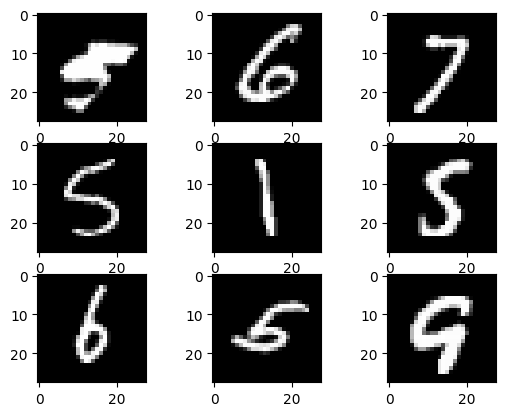

In [ ]:
import random
for i in range(9):
  plt.subplot(3,3,i+1)
  num = random.randint(0, len(x_train))
  plt.imshow(x_train[num], cmap='gray', interpolation='none')

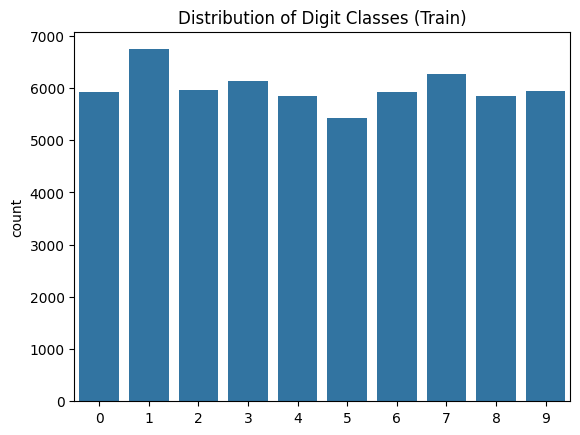

In [ ]:
sns.countplot(x=y_train)
plt.title("Distribution of Digit Classes (Train)")
plt.show()

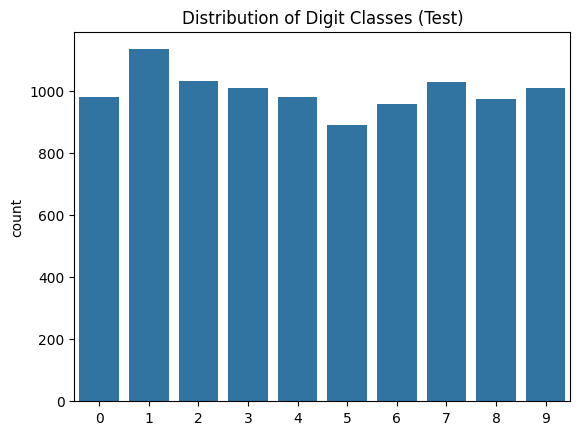

In [ ]:
sns.countplot(x=y_test)
plt.title("Distribution of Digit Classes (Test)")
plt.show()

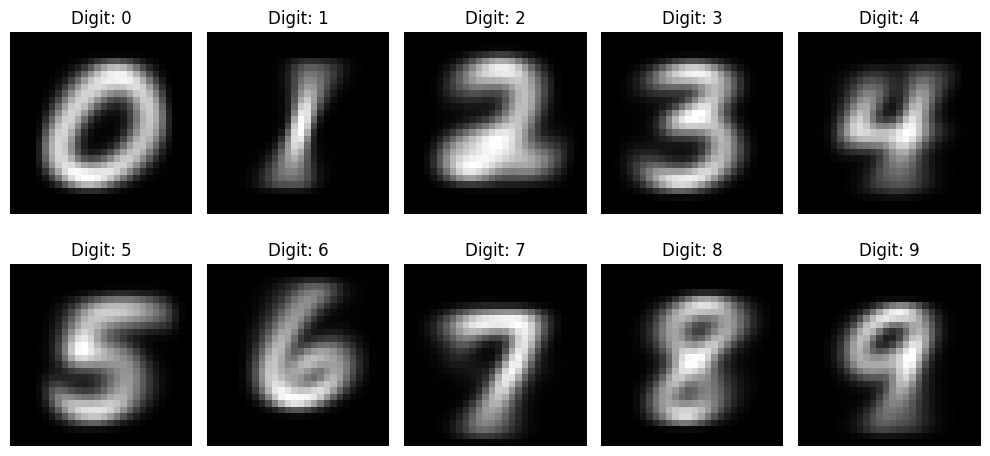

In [ ]:
average_digits = np.array([np.mean(x_train[y_train == i], axis=0) for i in range(10)])
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(average_digits[i], cmap='gray')
    ax.set_title(f"Digit: {i}")
    ax.axis('off')
plt.tight_layout()
plt.show()

# Models

In [ ]:
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

In [ ]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

### Build the CNN model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,  Activation

In [ ]:
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 48s 59ms/step - accuracy: 0.7953 - loss: 0.6303 - val_accuracy: 0.9783 - val_loss: 0.0746
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 58ms/step - accuracy: 0.9612 - loss: 0.1275 - val_accuracy: 0.9843 - val_loss: 0.0508
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 58ms/step - accuracy: 0.9716 - loss: 0.0895 - val_accuracy: 0.9876 - val_loss: 0.0426
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - accuracy: 0.9771 - loss: 0.0752 - val_accuracy: 0.9880 - val_loss: 0.0381
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 57ms/step - accuracy: 0.9820 - loss: 0.0597 - val_accuracy: 0.9904 - val_loss: 0.0341
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - accuracy: 0.9815 - loss: 0.0600 - val_accuracy: 0.9906 - val_loss: 0.0318
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - accuracy: 0.9850 - loss: 0.0493 - val_accuracy: 0.9898 - val_loss: 0.0341
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 57ms/step - accuracy: 0.9857 - loss: 0.0455 - 

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9912 - loss: 0.0278
Test Accuracy: 0.9927


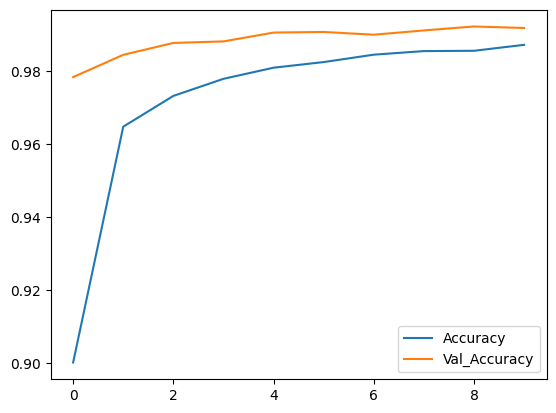

In [ ]:
plt.plot(range(10),history.history['accuracy'], label='Accuracy')
plt.plot(range(10),history.history['val_accuracy'], label='Val_Accuracy')
plt.legend()
plt.show()

## SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

In [ ]:

svm_model = SVC(kernel='rbf', C=1.0)
svm_model.fit(x_train_flat[:10000], np.argmax(y_train[:10000], axis=1))

SVC()

In [ ]:
y_pred_svm = svm_model.predict(x_test_flat)

In [ ]:
accuracy_svm = accuracy_score(np.argmax(y_test, axis=1), y_pred_svm)
print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.9594


## KNeighbors Classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(x_train_flat[:10000], np.argmax(y_train[:10000], axis=1))

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred_knn = knn_model.predict(x_test_flat)

In [ ]:
accuracy_knn = accuracy_score(np.argmax(y_test, axis=1), y_pred_knn)
print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.9463
